In [38]:
# ---- Librerias ----
import os
import glob
import json
import joblib
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

warnings.filterwarnings('ignore')

# ---- Configuracion global ----
SEED = 42
np.random.seed(SEED)

CLASSES = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']
SR = 16000
DURACION = 3.0
N_MUESTRAS = int(SR * DURACION)   # 48000

RUTA_CSV = '../Archivos-csv'
RUTA_MODELOS = '../Modelo-Entrenado'
os.makedirs(RUTA_CSV, exist_ok=True)
os.makedirs(RUTA_MODELOS, exist_ok=True)

# Todos los CSV compartidos viven en Archivos-csv/. El notebook nunca
# escribe CSV en su propia carpeta para no duplicar archivos.
RUTA_BASE     = os.path.join(RUTA_CSV, 'dataset_cremad_base.csv')
RUTA_FEATURES = os.path.join(RUTA_CSV, 'features_cremad.csv')
RUTA_PROBS    = os.path.join(RUTA_CSV, 'validation_probabilities.csv')
RUTA_SPLITS   = 'splits_actores_cremad.json'

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 50)

print('Clases:', CLASSES)
print('CSV compartidos en:', os.path.abspath(RUTA_CSV))
print(f'Muestreo: {SR} Hz | Duracion fija: {DURACION}s ({N_MUESTRAS} muestras)')

Clases: ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']
CSV compartidos en: c:\Users\Bryan26\Desktop\Carpeta_machine\Macine_grupal\CREMA--D-Assembly-\Archivos-csv
Muestreo: 16000 Hz | Duracion fija: 3.0s (48000 muestras)


### **EDA of the audio files** 

**Names of the audio files:** Author ID, Phrase, Emotion, Intensity of emotion.

**Phrases:** 
* IEO: It's eleven o'clock
* TIE: That is exactly what happened
* IOM: I'm on my way to the meeting
* IWW: I wonder what this is about
* TAI: The airplane is almost full
* MTI: Maybe tomorrow it will be cold
* IWL: I would like a new alarm clock
* ITH: I think I have a doctor's appointment
* DFA: Don't forget a jacket
* ITS: I think I've seen this before
* TSI: The surface is slick
* WSI: We'll stop in a couple of minutes

**Intensity of emotion:**
* LO: Low
* MD: Medium
* HI: High
* XX: Unspecified 

In [39]:
#Audio dataset root directory
DATASET_ROOT = "../AudioWAV"

In [40]:
import IPython.display as ipd
ipd.Audio(os.path.join(DATASET_ROOT, "1001_DFA_ANG_XX.wav"))

## Extraction Data
1. Extraction of the Minimum, Maximum, Averague  duration.
2. Extraction of the number by emotions.
3. Class distribution
4. Visualization of two spectrograms 

Total de audios: 7442
Frecuencias de muestreo: {16000}
Canales: {1}

Minima : 1.27 s
Maxima : 5.00 s
Media  : 2.54 s
Mediana: 2.50 s
  P75: 2.84 s
  P90: 3.17 s
  P95: 3.47 s
  P99: 4.04 s

Audios que superan 3.0s (se truncan): 1252 (16.82%)
Audios mas cortos (se repiten): 6190 (83.18%)


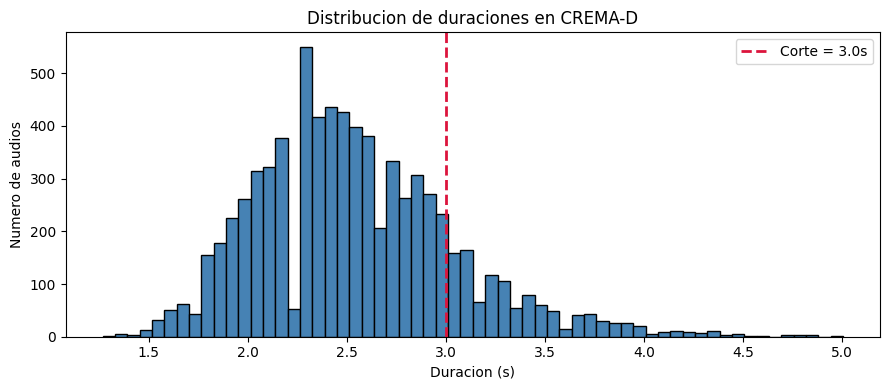

In [41]:
audio_files = sorted(glob.glob(os.path.join(DATASET_ROOT, "*.wav")))

info = [sf.info(f) for f in audio_files]
durations = np.array([i.duration for i in info])

print(f"Total de audios: {len(durations)}")
print(f"Frecuencias de muestreo: {set(i.samplerate for i in info)}")
print(f"Canales: {set(i.channels for i in info)}")
print(f"\nMinima : {durations.min():.2f} s")
print(f"Maxima : {durations.max():.2f} s")
print(f"Media  : {durations.mean():.2f} s")
print(f"Mediana: {np.median(durations):.2f} s")
for q in [75, 90, 95, 99]:
    print(f"  P{q}: {np.percentile(durations, q):.2f} s")

n_trunc = (durations > DURACION).sum()
print(f"\nAudios que superan {DURACION}s (se truncan): {n_trunc} ({100*n_trunc/len(durations):.2f}%)")
print(f"Audios mas cortos (se repiten): {len(durations)-n_trunc} ({100*(1-n_trunc/len(durations)):.2f}%)")

plt.figure(figsize=(9, 4))
plt.hist(durations, bins=60, color='steelblue', edgecolor='black')
plt.axvline(DURACION, color='crimson', ls='--', lw=2, label=f'Corte = {DURACION}s')
plt.xlabel('Duracion (s)'); plt.ylabel('Numero de audios')
plt.title('Distribucion de duraciones en CREMA-D'); plt.legend()
plt.tight_layout(); plt.show()

CSV base guardado en '../Archivos-csv\dataset_cremad_base.csv' con 7442 filas.

             sample_id id_actor true_label
0  1001_DFA_ANG_XX.wav     1001        ANG
1  1001_DFA_DIS_XX.wav     1001        DIS
2  1001_DFA_FEA_XX.wav     1001        FEA
3  1001_DFA_HAP_XX.wav     1001        HAP
4  1001_DFA_NEU_XX.wav     1001        NEU 

{'ANG': 1271, 'DIS': 1271, 'FEA': 1271, 'HAP': 1271, 'NEU': 1087, 'SAD': 1271}


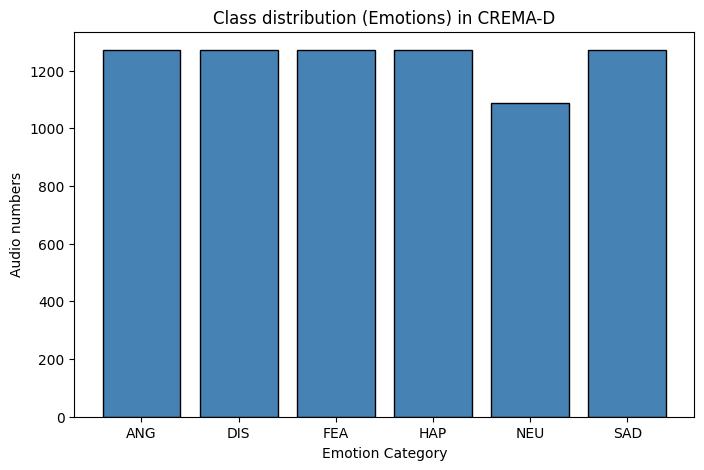

In [42]:
# ---- Metadatos base + distribucion de clases ----
# El CSV base se escribe en Archivos-csv/ (no en Notebook/) para que exista
# una sola copia compartida por el grupo.

count_emotions = {c: 0 for c in CLASSES}
datos_audios = []

for audio_file in audio_files:
    filename = os.path.basename(audio_file)
    partes = filename.split('_')
    if len(partes) >= 3:
        id_actor, emocion = partes[0], partes[2]
        count_emotions[emocion] += 1
        datos_audios.append({
            'sample_id': filename,
            'id_actor': id_actor,
            'true_label': emocion,
        })

df_metadatos = (pd.DataFrame(datos_audios)
                  .sort_values('sample_id')
                  .reset_index(drop=True))
df_metadatos.to_csv(RUTA_BASE, index=False)
print(f"CSV base guardado en '{RUTA_BASE}' con {len(df_metadatos)} filas.\n")
print(df_metadatos.head(), '\n')

print(count_emotions)

# ---- Distribucion de clases ----
plt.figure(figsize=(8, 5))
plt.bar(list(count_emotions.keys()), list(count_emotions.values()),
        color='steelblue', edgecolor='black')
plt.title('Class distribution (Emotions) in CREMA-D')
plt.xlabel('Emotion Category')
plt.ylabel('Audio numbers')
plt.show()

_(Se elimino la celda duplicada que volvia a contar las emociones y a dibujar la misma grafica: ya lo hace la celda anterior.)_

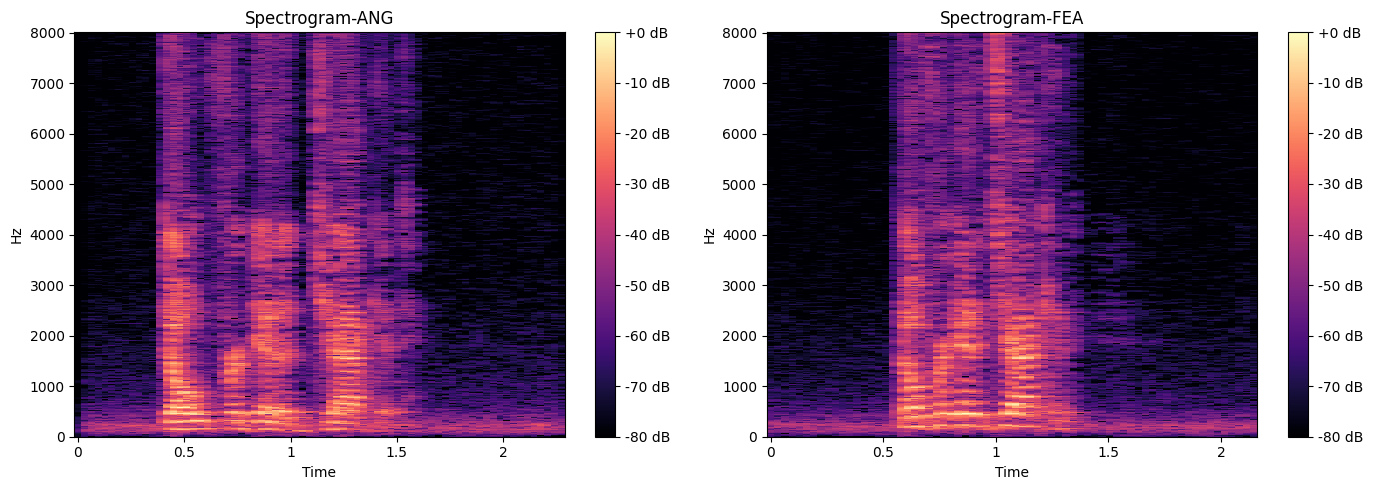

In [43]:
#Visualization of two spectrograms 
wav1, sr = librosa.load(os.path.join(DATASET_ROOT, "1001_DFA_ANG_XX.wav"), sr= None)
wav2, sr = librosa.load(os.path.join(DATASET_ROOT, "1001_DFA_FEA_XX.wav"), sr= None)


spec1 = librosa.amplitude_to_db(np.abs(librosa.stft(wav1)), ref=np.max)
spec2 = librosa.amplitude_to_db(np.abs(librosa.stft(wav2)), ref=np.max)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
img1 =librosa.display.specshow(spec1, y_axis='linear', x_axis= 'time', sr=sr, ax= ax[0])
ax[0].set_title('Spectrogram-ANG')
img2 =librosa.display.specshow(spec2, y_axis='linear', x_axis= 'time', sr=sr, ax= ax[1])
ax[1].set_title('Spectrogram-FEA')

fig.colorbar(img1, ax=ax[0], format="%+2.0f dB")
fig.colorbar(img2, ax=ax[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

### 

### **Promedio del Audio y ajuste**

In [44]:
# Processing audio files

def pad_or_truncate_audio(file_path, n=N_MUESTRAS, sr=SR):
    """
    Carga canonica compartida por los cinco modelos.
    - Trunca a 3 s los audios largos (16.8% del dataset)
    - Repite los cortos hasta completar 3 s (loop-padding)
    Devuelve siempre exactamente 48000 muestras.
    """
    try:
        wav, _ = librosa.load(file_path, sr=sr)
        if len(wav) >= n:
            return wav[:n], sr
        repeticiones = int(np.ceil(n / len(wav)))
        return np.tile(wav, repeticiones)[:n], sr
    except Exception as e:
        print(f"Error processing file {os.path.basename(file_path)}: {e}")
        return None, None

In [45]:
#test
wav_fixed, sr = pad_or_truncate_audio(os.path.join(DATASET_ROOT, "1001_DFA_ANG_XX.wav"))


print(f"Original duration: {librosa.get_duration(path=os.path.join(DATASET_ROOT, '1001_DFA_ANG_XX.wav')):.2f} seconds")
print(f"Fixed duration: {librosa.get_duration(y=wav_fixed, sr=sr):.2f} seconds")  # Assuming default sampling rate of 22050 Hz

Original duration: 2.28 seconds
Fixed duration: 3.00 seconds


### Data Leakage
Separados 70-15-15 pero por la cantidad de actores del dataset

In [46]:
def extraer_caracteristicas_acusticas(WAV_signal, tasa_muestreo=SR):
    mfcc   = librosa.feature.mfcc(y=WAV_signal, sr=tasa_muestreo, n_mfcc=20)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    c = {}
    for nombre, M in [('mfcc', mfcc), ('delta', delta), ('delta2', delta2)]:
        medias, desvs = M.mean(axis=1), M.std(axis=1)
        for i in range(M.shape[0]):
            c[f'{nombre}_{i+1}_mean'] = medias[i]
            c[f'{nombre}_{i+1}_std']  = desvs[i]

    c['tasa_cruces_cero']      = float(np.mean(librosa.feature.zero_crossing_rate(y=WAV_signal)))
    c['centroide_espectral']   = float(np.mean(librosa.feature.spectral_centroid(y=WAV_signal, sr=tasa_muestreo)))
    c['energia_rms']           = float(np.mean(librosa.feature.rms(y=WAV_signal)))
    c['rolloff_espectral']     = float(np.mean(librosa.feature.spectral_rolloff(y=WAV_signal, sr=tasa_muestreo, roll_percent=0.85)))
    c['ancho_banda_espectral'] = float(np.mean(librosa.feature.spectral_bandwidth(y=WAV_signal, sr=tasa_muestreo)))
    c['contraste_espectral']   = float(np.mean(librosa.feature.spectral_contrast(y=WAV_signal, sr=tasa_muestreo)))
    c['plenitud_espectral']    = float(np.mean(librosa.feature.spectral_flatness(y=WAV_signal)))
    return c

In [47]:
def procesar_dataset_y_crear_dataframe(ruta_dataset):
    """
    Itera sobre los audios, ajusta su duracion y extrae caracteristicas.
    Ordena por sample_id para que todos los integrantes obtengan
    las filas en el mismo orden, sin depender de glob.
    """
    rutas_archivos_audio = glob.glob(os.path.join(ruta_dataset, "*.wav"))
    lista_datos_completos = []
    total_archivos = len(rutas_archivos_audio)

    print(f"Iniciando extraccion de caracteristicas de {total_archivos} archivos...")

    for contador, ruta_archivo in enumerate(rutas_archivos_audio, start=1):
        nombre_archivo = os.path.basename(ruta_archivo)
        partes_nombre = nombre_archivo.split('_')

        if len(partes_nombre) >= 3:
            id_actor = partes_nombre[0]
            etiqueta_emocion = partes_nombre[2]

            audio_ajustado, tasa_muestreo = pad_or_truncate_audio(ruta_archivo)

            if audio_ajustado is not None:
                datos_fila = extraer_caracteristicas_acusticas(audio_ajustado, tasa_muestreo)
                datos_fila['sample_id'] = nombre_archivo
                datos_fila['id_actor']  = id_actor
                datos_fila['emocion']   = etiqueta_emocion
                lista_datos_completos.append(datos_fila)

        if contador % 500 == 0:
            print(f"Procesados {contador} de {total_archivos} audios...")

    print("Extraccion completada.")
    return pd.DataFrame(lista_datos_completos).sort_values('sample_id').reset_index(drop=True)

In [48]:
# ---- Extraccion de caracteristicas (con cache) ----
# Si features_cremad.csv ya existe se reutiliza: reprocesar los 7442 audios
# tarda varios minutos y el resultado es identico (la extraccion es determinista).
# Para forzar el recalculo pon RECALCULAR_FEATURES = True.

RECALCULAR_FEATURES = False

if (not RECALCULAR_FEATURES) and os.path.exists(RUTA_FEATURES):
    df_caracteristicas = pd.read_csv(RUTA_FEATURES)
    df_caracteristicas['id_actor'] = df_caracteristicas['id_actor'].astype(str)
    print(f'Caracteristicas cargadas desde {RUTA_FEATURES}')
else:
    df_caracteristicas = procesar_dataset_y_crear_dataframe(DATASET_ROOT)
    df_caracteristicas.to_csv(RUTA_FEATURES, index=False)
    print(f'Caracteristicas guardadas en {RUTA_FEATURES}')

print(df_caracteristicas.shape)          # esperado: (7442, 130)
print(df_caracteristicas['sample_id'].is_unique)
df_caracteristicas.head()

Caracteristicas cargadas desde ../Archivos-csv\features_cremad.csv
(7442, 130)
True


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,mfcc_6_mean,mfcc_6_std,mfcc_7_mean,mfcc_7_std,mfcc_8_mean,mfcc_8_std,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,...,delta2_13_std,delta2_14_mean,delta2_14_std,delta2_15_mean,delta2_15_std,delta2_16_mean,delta2_16_std,delta2_17_mean,delta2_17_std,delta2_18_mean,delta2_18_std,delta2_19_mean,delta2_19_std,delta2_20_mean,delta2_20_std,tasa_cruces_cero,centroide_espectral,energia_rms,rolloff_espectral,ancho_banda_espectral,contraste_espectral,plenitud_espectral,sample_id,id_actor,emocion
0,-306.94455,161.495420,94.363420,27.566635,10.055119,33.235300,22.259483,18.526869,5.779584,20.003164,-5.614751,17.808657,-9.813098,14.673255,-10.095236,15.400408,-5.265654,6.991499,-13.033746,7.543640,0.514165,7.422677,-10.143759,8.294315,-5.955340,...,0.860958,-0.026949,1.053571,0.015169,0.633071,-0.042829,0.903629,0.042528,0.675324,0.055185,0.634657,0.002610,0.763219,-0.027480,0.691229,0.097319,1561.377525,0.044587,3208.444149,1804.235155,17.695071,0.024719,1001_DFA_ANG_XX.wav,1001,ANG
1,-355.88120,121.131454,97.562614,23.529482,12.001207,28.857822,30.913574,13.492492,15.575253,12.887399,-4.891905,17.574656,-5.722921,11.151229,-5.124552,11.305930,-5.438893,8.334834,-9.735347,5.512251,-2.169454,7.912293,-7.077807,6.440149,-6.628007,...,0.709695,0.032078,0.671813,0.006466,0.510917,0.006042,0.658202,-0.015539,0.612727,0.034427,0.390973,0.082750,0.714534,-0.036726,0.679481,0.085475,1488.787940,0.015736,3039.893617,1794.424087,16.549577,0.022884,1001_DFA_DIS_XX.wav,1001,DIS
2,-324.73798,166.712570,97.263180,20.042433,9.348844,31.935633,21.147984,17.946167,10.948439,15.944604,-5.452253,17.506330,-7.649064,13.833654,-6.031546,11.028845,-5.832608,6.488420,-13.302959,8.325360,-3.463395,6.696230,-8.775144,5.304351,-6.832579,...,0.749406,0.094802,1.091607,0.011308,0.427846,0.058775,0.626696,0.051735,0.782318,-0.052915,0.618021,-0.010305,0.659100,0.037773,0.595116,0.079257,1451.841364,0.045135,2980.634973,1802.213722,17.190227,0.017177,1001_DFA_FEA_XX.wav,1001,FEA
3,-269.40130,156.146710,89.331570,23.537611,-0.507037,29.448124,26.549429,18.175160,7.733314,18.879517,-14.234652,18.799410,-12.094867,13.919965,-10.051626,13.717805,-7.544462,9.228237,-18.195396,9.030563,0.163942,7.982137,-9.209809,7.036780,-9.929687,...,0.913364,0.093530,1.070347,0.045299,1.024252,-0.005430,0.728189,-0.102028,0.684821,-0.077821,0.832878,0.004063,0.707974,0.058978,0.724442,0.093662,1628.602442,0.051515,3299.035904,1807.360061,17.880022,0.020990,1001_DFA_HAP_XX.wav,1001,HAP
4,-321.42600,109.912610,98.977340,25.306738,7.985224,24.491617,29.238186,15.077043,10.251309,17.905144,-3.592251,14.818153,-9.673445,16.817440,-11.447524,12.636653,-6.652886,9.643683,-13.258989,9.191231,1.791616,10.258380,-10.547569,8.565592,-2.878854,...,1.206173,-0.053005,1.004802,0.006272,0.628292,-0.064992,0.788980,-0.007915,0.652712,0.080547,0.809937,-0.055802,0.439023,0.042974,0.683287,0.083595,1527.712642,0.024221,3161.402926,1779.618201,17.235060,0.021686,1001_DFA_NEU_XX.wav,1001,NEU


Train: 5152 audios (69.2%) | 63 actores
Val  : 1142 audios (15.3%) | 14 actores
Test : 1148 audios (15.4%) | 14 actores

Verificacion speaker-disjoint:
  Train ∩ Val : set()
  Train ∩ Test: set()
  Val   ∩ Test: set()
>>> Sin fuga de hablantes.

Distribucion de emociones por particion:
         Train  Validation  Test
emocion                         
ANG        880         195   196
DIS        880         195   196
FEA        880         195   196
HAP        880         195   196
NEU        752         167   168
SAD        880         195   196

Proporciones:
         Train  Validation   Test
emocion                          
ANG      0.171       0.171  0.171
DIS      0.171       0.171  0.171
FEA      0.171       0.171  0.171
HAP      0.171       0.171  0.171
NEU      0.146       0.146  0.146
SAD      0.171       0.171  0.171


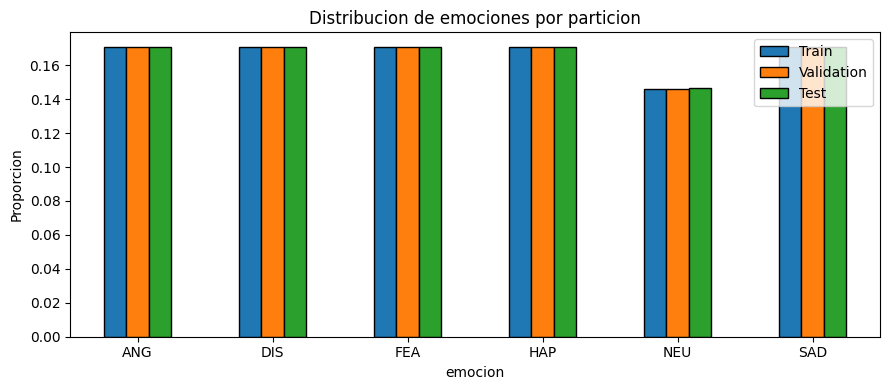

In [49]:
# ---- Split oficial del grupo: se CARGA, no se recalcula ----
with open(RUTA_SPLITS, encoding='utf-8') as f:
    splits = json.load(f)

# Los ids del JSON son cadenas; se normalizan por si alguien los guardo como int.
splits = {k: [str(a) for a in v] for k, v in splits.items()}

X = df_caracteristicas.drop(columns=['sample_id', 'id_actor', 'emocion'])
y = df_caracteristicas['emocion']
actores = df_caracteristicas['id_actor'].astype(str)

idx_train = np.where(actores.isin(splits['train']))[0]
idx_val   = np.where(actores.isin(splits['val']))[0]
idx_test  = np.where(actores.isin(splits['test']))[0]

X_train, X_val, X_test = X.iloc[idx_train], X.iloc[idx_val], X.iloc[idx_test]
y_train, y_val, y_test = y.iloc[idx_train], y.iloc[idx_val], y.iloc[idx_test]

set_train = set(actores.iloc[idx_train])
set_val   = set(actores.iloc[idx_val])
set_test  = set(actores.iloc[idx_test])

print(f"Train: {len(idx_train)} audios ({100*len(idx_train)/len(X):.1f}%) | {len(set_train)} actores")
print(f"Val  : {len(idx_val)} audios ({100*len(idx_val)/len(X):.1f}%) | {len(set_val)} actores")
print(f"Test : {len(idx_test)} audios ({100*len(idx_test)/len(X):.1f}%) | {len(set_test)} actores")

print("\nVerificacion speaker-disjoint:")
print(f"  Train ∩ Val : {set_train & set_val}")
print(f"  Train ∩ Test: {set_train & set_test}")
print(f"  Val   ∩ Test: {set_val & set_test}")

assert len(idx_train) + len(idx_val) + len(idx_test) == len(X), "Hay actores fuera del split"
assert not (set_train & set_val) and not (set_train & set_test) and not (set_val & set_test)
print(">>> Sin fuga de hablantes.")

# ---- Distribucion de emociones por particion ----
dist = pd.concat([
    y.iloc[idx_train].value_counts().rename('Train'),
    y.iloc[idx_val].value_counts().rename('Validation'),
    y.iloc[idx_test].value_counts().rename('Test'),
], axis=1).reindex(CLASSES)

print("\nDistribucion de emociones por particion:")
print(dist)
print("\nProporciones:")
print((dist / dist.sum()).round(3))

(dist / dist.sum()).plot(kind='bar', figsize=(9, 4), edgecolor='black')
plt.title('Distribucion de emociones por particion'); plt.ylabel('Proporcion')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [50]:
# import json

# # 1. Convertir los sets a listas (JSON no soporta formato 'set')
# distribucion_actores = {
#     "train": list(set_train),
#     "val": list(set_val),
#     "test": list(set_test)
# }

# # 2. Guardar en un archivo JSON
# ruta_archivo = "splits_actores_cremad.json"
# with open(ruta_archivo, "w") as f:
#     json.dump(distribucion_actores, f, indent=4)

# print(f"Distribución exportada exitosamente en '{ruta_archivo}'")

## Modelos 

#### Intrucciones:
* Explicar claramente cómo representa el audio y pq se eligieorn el modelo y que caracteristicas se deben extraer.
* Entrenar el modelo con el set separado (Ejecutar la siguiente celda para obtener estas divisiones del dataset)
* Cuando el modelo este entrenado Exportar como archivo pkl y guardarlo en Modelo-Entrenado.
* Obtener los resultados de las metricas y guardar en un archivo "modelo.text" (Para luego hacer la matriz de confunsion)
* **En caso de que el modelo entre dentro de estos conceptos hacer con el set de validation:**
**Modelos de Machine Learning Tradicional (SVM, Regresión Logística, Random Forest):** Aquí generalmente no hay "épocas" de entrenamiento iterativo, por lo que no usarás early stopping ni guardarás "checkpoints". El conjunto de Validation te servirá únicamente para ajustar hiperparámetros (como evaluar qué valor de C es mejor para el SVM, o cuántos estimadores necesita el Random Forest).
**Deep Learning (CNN, LSTM, Modelos preentrenados como HuBERT):** Estos modelos sí aprenden de forma iterativa a lo largo de varias épocas. Aquí sí es casi obligatorio usar Validation para monitorear el loss, aplicar early stopping para no sobreajustar, y guardar el mejor checkpoint de los pesos de la red.
* Sacar las probabilidades y AGREGAR en Archivos-csv/Probabilidades.csv las probabilidades que extraen de su modelo (Codigo mas abajo)

In [51]:
# Division en Train/Val/Test a partir del JSON oficial.
# Reutiliza el dict `splits` cargado en la celda anterior (no lo vuelve a leer)
# y produce exactamente las mismas particiones.

def aplicar_particion_json(df, splits=splits):
    ids = df['id_actor'].astype(str)
    cols_meta = ['sample_id', 'id_actor', 'emocion', 'true_label']

    def parte(nombre):
        sub = df[ids.isin(splits[nombre])]
        return sub.drop(columns=cols_meta, errors='ignore'), sub['emocion']

    X_tr, y_tr = parte('train')
    X_va, y_va = parte('val')
    X_te, y_te = parte('test')
    return X_tr, y_tr, X_va, y_va, X_te, y_te


X_train, y_train, X_val, y_val, X_test, y_test = aplicar_particion_json(df_caracteristicas)

# Deben coincidir con los indices de la celda anterior; si no, ids_val/ids_test
# quedarian desalineados con las probabilidades sin que nadie lo note.
assert list(X_train.index) == list(idx_train)
assert list(X_val.index) == list(idx_val)
assert list(X_test.index) == list(idx_test)

print(f"Audios Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Audios Train: 5152 | Val: 1142 | Test: 1148


In [52]:
NOMBRES = {'ANG': 'anger', 'DIS': 'disgust', 'FEA': 'fear',
           'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad'}


def agregar_probabilidades_modelo(probabilidades, clases_modelo, num_modelo,
                                  ids_val, y_val_true, ruta_csv=RUTA_PROBS):
    """
    Anade las probabilidades de un modelo al CSV compartido, alineando por
    sample_id (asi el orden de filas de cada integrante no importa).

    Si el archivo existente no es un CSV de probabilidades valido -por ejemplo
    si alguien copio encima el dataset base- se reconstruye desde cero en vez
    de abortar con un assert.
    """
    idx = [list(clases_modelo).index(c) for c in CLASSES]
    P = np.asarray(probabilidades)[:, idx]

    assert P.shape == (len(ids_val), 6), f'Shape inesperado: {P.shape}'
    assert np.allclose(P.sum(axis=1), 1.0), 'Las probabilidades no suman 1'

    nuevo = pd.DataFrame({'sample_id': ids_val, 'true_label': y_val_true})
    for j, c in enumerate(CLASSES):
        nuevo[f'prob_model_{num_modelo}_{NOMBRES[c]}'] = P[:, j]

    base = None
    if os.path.exists(ruta_csv):
        base = pd.read_csv(ruta_csv)
        cols_prob = [c for c in base.columns if c.startswith('prob_model_')]
        mismos_ids = set(base.get('sample_id', [])) == set(nuevo['sample_id'])

        if not cols_prob or not mismos_ids:
            print(f'AVISO: {ruta_csv} no era un CSV de probabilidades de validation '
                  f'({len(base)} filas, {len(cols_prob)} columnas prob_model_*). '
                  f'Se reconstruye con el Modelo {num_modelo}.')
            base = None

    if base is None:
        df = nuevo
        print(f'CSV creado con el Modelo {num_modelo}.')
    else:
        # Elimina columnas previas de este mismo modelo (permite reejecutar)
        prev = [c for c in base.columns if c.startswith(f'prob_model_{num_modelo}_')]
        base = base.drop(columns=prev)
        df = base.merge(nuevo.drop(columns=['true_label']), on='sample_id', how='left')
        assert df.filter(like='prob_model_').isna().sum().sum() == 0, 'Hay filas sin alinear'
        print(f'Modelo {num_modelo} anadido al CSV existente.')

    df = df.sort_values('sample_id').reset_index(drop=True)
    df.to_csv(ruta_csv, index=False)
    print(f'Guardado: {ruta_csv}  ->  {df.shape}')
    return df

In [53]:
# ---- Vistas de caracteristicas por modelo ----
COLS_META = ['sample_id', 'id_actor', 'emocion']
COLS_NUM  = [c for c in df_caracteristicas.columns if c not in COLS_META]

cols_mfcc   = [c for c in COLS_NUM if c.startswith('mfcc_')]
cols_delta  = [c for c in COLS_NUM if c.startswith(('delta_', 'delta2_'))]
cols_espec  = ['tasa_cruces_cero', 'centroide_espectral', 'energia_rms',
               'rolloff_espectral', 'ancho_banda_espectral',
               'contraste_espectral', 'plenitud_espectral']

vista_m1 = cols_mfcc                                              # SVC         40d
vista_m2 = cols_mfcc + cols_delta                                 # LogReg     120d
vista_m3 = cols_espec + [c for c in cols_mfcc if c.endswith('_mean')]  # RF      27d
vista_m4 = COLS_NUM                                               # ExtraTrees 127d

for n, v in [('M1 SVC', vista_m1), ('M2 LogReg', vista_m2),
             ('M3 RF', vista_m3), ('M4 ExtraTrees', vista_m4)]:
    print(f'{n:15s} {len(v):4d} caracteristicas')


# ---- Utilidades de evaluacion ----
def evaluar(y_true, y_pred, nombre, representacion=''):
    return {
        'Modelo': nombre,
        'Representacion': representacion,
        'Accuracy':        accuracy_score(y_true, y_pred),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', labels=CLASSES, zero_division=0),
        'Macro Recall':    recall_score(y_true, y_pred, average='macro', labels=CLASSES, zero_division=0),
        'Macro F1':        f1_score(y_true, y_pred, average='macro', labels=CLASSES, zero_division=0),
        'Weighted F1':     f1_score(y_true, y_pred, average='weighted', labels=CLASSES, zero_division=0),
    }


def matriz_confusion(y_true, y_pred, titulo, normalizar=True):
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True) if normalizar else cm
    fig, ax = plt.subplots(figsize=(6, 5.2))
    ConfusionMatrixDisplay(cm_plot, display_labels=CLASSES).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='.2f' if normalizar else 'd')
    ax.set_title(titulo); plt.tight_layout(); plt.show()
    return cm


def probs_ordenadas(modelo, X):
    """predict_proba reordenado al orden global CLASSES."""
    P = modelo.predict_proba(X)
    idx = [list(modelo.classes_).index(c) for c in CLASSES]
    return P[:, idx]


def pred_desde_probs(P):
    return np.array(CLASSES)[P.argmax(axis=1)]


# ---- Identificadores alineados por particion ----
ids_val  = df_caracteristicas.iloc[idx_val]['sample_id'].values
ids_test = df_caracteristicas.iloc[idx_test]['sample_id'].values
print(f'\nids_val: {len(ids_val)} | ids_test: {len(ids_test)}')

M1 SVC            40 caracteristicas
M2 LogReg        120 caracteristicas
M3 RF             27 caracteristicas
M4 ExtraTrees    127 caracteristicas

ids_val: 1142 | ids_test: 1148


### Modelo 1 

In [54]:
# =====================================================
# MODELO 1 — SVM con kernel RBF
# Representacion: MFCC mean + std (40 dimensiones)
# =====================================================

Xtr_m1 = X_train[vista_m1].values
Xva_m1 = X_val[vista_m1].values
Xte_m1 = X_test[vista_m1].values
print(f'Train {Xtr_m1.shape} | Val {Xva_m1.shape} | Test {Xte_m1.shape}')

# ---- Busqueda de hiperparametros SOBRE VALIDATION ----
# Se usa probability=False aqui porque solo hacen falta las predicciones;
# asi la busqueda es varias veces mas rapida.
resultados_grid = []
for C in [1, 3, 10, 30]:
    for gamma in ['scale', 0.01, 0.02]:
        m = Pipeline([('scaler', StandardScaler()),
                      ('clf', SVC(kernel='rbf', C=C, gamma=gamma, random_state=SEED))])
        m.fit(Xtr_m1, y_train)
        pred = m.predict(Xva_m1)
        resultados_grid.append({
            'C': C, 'gamma': gamma,
            'Accuracy': accuracy_score(y_val, pred),
            'Macro F1': f1_score(y_val, pred, average='macro', labels=CLASSES, zero_division=0),
        })

grid = pd.DataFrame(resultados_grid).sort_values('Macro F1', ascending=False)
print(grid.to_string(index=False))

mejor = grid.iloc[0]
C_best, gamma_best = mejor['C'], mejor['gamma']
print(f"\nMejor configuracion: C={C_best}, gamma={gamma_best}")

Train (5152, 40) | Val (1142, 40) | Test (1148, 40)


 C gamma  Accuracy  Macro F1
 1 scale  0.505254  0.494030
 1  0.02  0.504378  0.492870
 3  0.02  0.496497  0.491093
 3 scale  0.494746  0.490822
10  0.01  0.492995  0.489059
 3  0.01  0.500000  0.489057
 1  0.01  0.495622  0.479929
30  0.01  0.476357  0.475058
10  0.02  0.464974  0.463188
10 scale  0.460595  0.459401
30  0.02  0.443958  0.442024
30 scale  0.429072  0.427950

Mejor configuracion: C=1, gamma=scale


Modelo                      M1_SVC_RBF
Representacion     MFCC mean+std (40d)
Accuracy                      0.496497
Macro Precision               0.503831
Macro Recall                  0.494647
Macro F1                      0.486222
Weighted F1                   0.488941

              precision    recall  f1-score   support

         ANG       0.70      0.68      0.69       195
         DIS       0.44      0.32      0.37       195
         FEA       0.58      0.30      0.40       195
         HAP       0.44      0.54      0.49       195
         NEU       0.34      0.42      0.38       167
         SAD       0.52      0.71      0.60       195

    accuracy                           0.50      1142
   macro avg       0.50      0.49      0.49      1142
weighted avg       0.51      0.50      0.49      1142

Discrepancia predict() vs argmax(proba): 5.87%


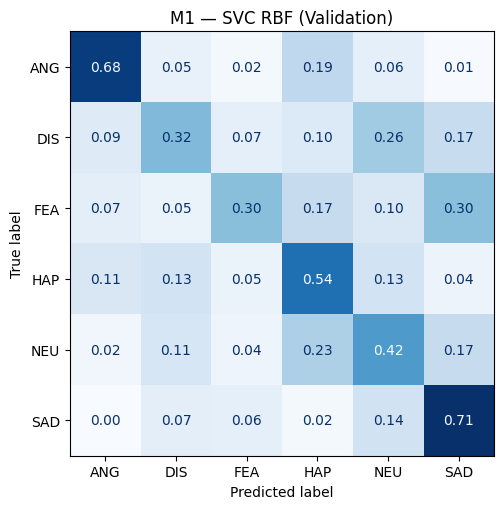

Recall por clase:
SAD    0.713
ANG    0.677
HAP    0.538
NEU    0.419
DIS    0.318
FEA    0.303
dtype: float64


In [55]:
# ---- Entrenamiento final con probabilidades calibradas ----
m1 = Pipeline([('scaler', StandardScaler()),
               ('clf', SVC(kernel='rbf', C=C_best, gamma=gamma_best,
                           probability=True, random_state=SEED))])
m1.fit(Xtr_m1, y_train)

P_val_m1  = probs_ordenadas(m1, Xva_m1)
P_test_m1 = probs_ordenadas(m1, Xte_m1)
pred_val_m1 = pred_desde_probs(P_val_m1)

res_m1 = evaluar(y_val, pred_val_m1, 'M1_SVC_RBF', 'MFCC mean+std (40d)')
print(pd.Series(res_m1).to_string())
print()
print(classification_report(y_val, pred_val_m1, labels=CLASSES, zero_division=0))

# Comprobaciones de integridad
assert P_val_m1.shape == (len(y_val), 6)
assert np.allclose(P_val_m1.sum(axis=1), 1.0)
print(f"Discrepancia predict() vs argmax(proba): "
      f"{100*(m1.predict(Xva_m1) != pred_val_m1).mean():.2f}%")

cm_m1 = matriz_confusion(y_val, pred_val_m1, 'M1 — SVC RBF (Validation)')
print('Recall por clase:')
print(pd.Series(np.diag(cm_m1)/cm_m1.sum(axis=1), index=CLASSES).round(3).sort_values(ascending=False))

In [56]:
# ---- Persistencia ----
joblib.dump(m1, os.path.join(RUTA_MODELOS, 'modelo_m1_svc.pkl'))
np.save(os.path.join(RUTA_CSV, 'P_val_m1.npy'), P_val_m1)
np.save(os.path.join(RUTA_CSV, 'P_test_m1.npy'), P_test_m1)

df_probs = agregar_probabilidades_modelo(
    probabilidades=P_val_m1,
    clases_modelo=CLASSES,          # P_val_m1 ya viene en orden CLASSES
    num_modelo=1,
    ids_val=ids_val,
    y_val_true=y_val.values,
)
df_probs.head()

Modelo 1 anadido al CSV existente.
Guardado: ../Archivos-csv\validation_probabilities.csv  ->  (1142, 14)


,sample_id,true_label,prob_model_2_anger,prob_model_2_disgust,prob_model_2_fear,prob_model_2_happy,prob_model_2_neutral,prob_model_2_sad,prob_model_1_anger,prob_model_1_disgust,prob_model_1_fear,prob_model_1_happy,prob_model_1_neutral,prob_model_1_sad
0,1011_DFA_ANG_XX.wav,ANG,0.928217,0.029242,0.002798,0.020721,0.018959,0.000063,0.635121,0.057398,0.022898,0.268938,0.013992,0.001653
1,1011_DFA_DIS_XX.wav,DIS,0.001822,0.064147,0.023575,0.037705,0.649659,0.223091,0.001530,0.159167,0.121464,0.009674,0.182396,0.525770
2,1011_DFA_FEA_XX.wav,FEA,0.000620,0.018285,0.630530,0.046322,0.045970,0.258273,0.002863,0.030140,0.444824,0.010766,0.030685,0.480722
3,1011_DFA_HAP_XX.wav,HAP,0.003017,0.021045,0.130852,0.055522,0.408482,0.381083,0.014446,0.263084,0.191436,0.124978,0.241948,0.164107
4,1011_DFA_NEU_XX.wav,NEU,0.000344,0.058884,0.136242,0.069183,0.322613,0.412734,0.001808,0.076894,0.244655,0.018347,0.248033,0.410263


### Modelo 2

In [57]:
# =====================================================
# MODELO 2 — Regresion Logistica multinomial
# Representacion: MFCC + delta + delta2, mean + std (120 dimensiones)
# =====================================================

Xtr_m2 = X_train[vista_m2].values
Xva_m2 = X_val[vista_m2].values
Xte_m2 = X_test[vista_m2].values
print(f'Train {Xtr_m2.shape} | Val {Xva_m2.shape} | Test {Xte_m2.shape}')

# ---- Busqueda de hiperparametros SOBRE VALIDATION ----
resultados_grid_m2 = []
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    m = Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(C=C, max_iter=3000, random_state=SEED))])
    m.fit(Xtr_m2, y_train)
    pred = m.predict(Xva_m2)
    resultados_grid_m2.append({
        'C': C,
        'Accuracy': accuracy_score(y_val, pred),
        'Macro F1': f1_score(y_val, pred, average='macro', labels=CLASSES, zero_division=0),
    })

grid_m2 = pd.DataFrame(resultados_grid_m2).sort_values('Macro F1', ascending=False)
print(grid_m2.to_string(index=False))

mejor_m2 = grid_m2.iloc[0]
C_best_m2 = mejor_m2['C']
print(f"\nMejor configuracion: C={C_best_m2}")

Train (5152, 120) | Val (1142, 120) | Test (1148, 120)
      C  Accuracy  Macro F1
 10.000  0.515762  0.509457
100.000  0.513135  0.506913
  1.000  0.512259  0.506036
  0.100  0.507005  0.500952
  0.010  0.489492  0.477747
  0.001  0.454466  0.429171

Mejor configuracion: C=10.0


Modelo                                     M2_LogReg
Representacion     MFCC+delta+delta2 mean+std (120d)
Accuracy                                    0.515762
Macro Precision                             0.515528
Macro Recall                                0.514596
Macro F1                                    0.509457
Weighted F1                                 0.511353

              precision    recall  f1-score   support

         ANG       0.67      0.70      0.69       195
         DIS       0.42      0.36      0.39       195
         FEA       0.60      0.43      0.50       195
         HAP       0.48      0.44      0.46       195
         NEU       0.40      0.47      0.43       167
         SAD       0.52      0.69      0.59       195

    accuracy                           0.52      1142
   macro avg       0.52      0.51      0.51      1142
weighted avg       0.52      0.52      0.51      1142

Discrepancia predict() vs argmax(proba): 0.00%


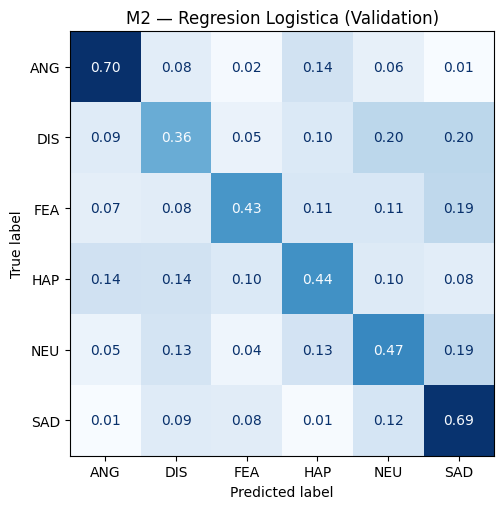

Recall por clase:
ANG    0.703
SAD    0.692
NEU    0.467
HAP    0.441
FEA    0.426
DIS    0.359
dtype: float64


In [58]:
# ---- Entrenamiento final ----
m2 = Pipeline([('scaler', StandardScaler()),
               ('clf', LogisticRegression(C=C_best_m2, max_iter=3000, random_state=SEED))])
m2.fit(Xtr_m2, y_train)

P_val_m2  = probs_ordenadas(m2, Xva_m2)
P_test_m2 = probs_ordenadas(m2, Xte_m2)
pred_val_m2 = pred_desde_probs(P_val_m2)

res_m2 = evaluar(y_val, pred_val_m2, 'M2_LogReg', 'MFCC+delta+delta2 mean+std (120d)')
print(pd.Series(res_m2).to_string())
print()
print(classification_report(y_val, pred_val_m2, labels=CLASSES, zero_division=0))

# Comprobaciones de integridad
assert P_val_m2.shape == (len(y_val), 6)
assert np.allclose(P_val_m2.sum(axis=1), 1.0)
print(f"Discrepancia predict() vs argmax(proba): "
      f"{100*(m2.predict(Xva_m2) != pred_val_m2).mean():.2f}%")

cm_m2 = matriz_confusion(y_val, pred_val_m2, 'M2 — Regresion Logistica (Validation)')
print('Recall por clase:')
print(pd.Series(np.diag(cm_m2)/cm_m2.sum(axis=1), index=CLASSES).round(3).sort_values(ascending=False))

In [59]:
# ---- Persistencia ----
joblib.dump(m2, os.path.join(RUTA_MODELOS, 'modelo_m2_logreg.pkl'))
np.save(os.path.join(RUTA_CSV, 'P_val_m2.npy'), P_val_m2)
np.save(os.path.join(RUTA_CSV, 'P_test_m2.npy'), P_test_m2)

df_probs = agregar_probabilidades_modelo(
    probabilidades=P_val_m2,
    clases_modelo=CLASSES,          # P_val_m2 ya viene en orden CLASSES
    num_modelo=2,
    ids_val=ids_val,
    y_val_true=y_val.values,
)
df_probs.head()

Modelo 2 anadido al CSV existente.
Guardado: ../Archivos-csv\validation_probabilities.csv  ->  (1142, 14)


,sample_id,true_label,prob_model_1_anger,prob_model_1_disgust,prob_model_1_fear,prob_model_1_happy,prob_model_1_neutral,prob_model_1_sad,prob_model_2_anger,prob_model_2_disgust,prob_model_2_fear,prob_model_2_happy,prob_model_2_neutral,prob_model_2_sad
0,1011_DFA_ANG_XX.wav,ANG,0.635121,0.057398,0.022898,0.268938,0.013992,0.001653,0.928014,0.029309,0.002812,0.020785,0.019016,0.000063
1,1011_DFA_DIS_XX.wav,DIS,0.001530,0.159167,0.121464,0.009674,0.182396,0.525770,0.001846,0.064145,0.023714,0.037791,0.650309,0.222195
2,1011_DFA_FEA_XX.wav,FEA,0.002863,0.030140,0.444824,0.010766,0.030685,0.480722,0.000615,0.018384,0.629102,0.046110,0.046105,0.259683
3,1011_DFA_HAP_XX.wav,HAP,0.014446,0.263084,0.191436,0.124978,0.241948,0.164107,0.003046,0.021264,0.130941,0.056101,0.409625,0.379023
4,1011_DFA_NEU_XX.wav,NEU,0.001808,0.076894,0.244655,0.018347,0.248033,0.410263,0.000349,0.058902,0.136795,0.069544,0.322691,0.411718


### Modelo 3  


### Modelo 4

### Modelo 5